In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from tensorflow.keras.metrics import Precision, Recall

from sklearn.preprocessing import label_binarize

In [2]:
TRAIN_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/train"
VAL_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/val"
TEST_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/test"

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1234 images belonging to 3 classes.


Found 265 images belonging to 3 classes.
Found 265 images belonging to 3 classes.


In [6]:
print(train_generator.class_indices)

{'class_1': 0, 'class_2': 1, 'class_3': 2}


In [7]:
# Get training labels
train_labels = train_generator.classes

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights_dict)

Class Weights:
{0: np.float64(0.7254556143445032), 1: np.float64(1.033500837520938), 2: np.float64(1.5291201982651796)}


In [8]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [10]:
#model.summary()

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [12]:
checkpoint = ModelCheckpoint(
    filepath=r"E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_best.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights_dict,
    callbacks=[
        checkpoint,
        early_stop,
        lr_reduce
    ]
)

Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.4238 - loss: 1.3983 - precision: 0.4309 - recall: 0.3595
Epoch 1: val_loss improved from None to 0.71412, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_best.keras

Epoch 1: finished saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_best.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.4951 - loss: 1.2220 - precision: 0.5035 - recall: 0.4117 - val_accuracy: 0.6717 - val_loss: 0.7141 - val_precision: 0.7720 - val_recall: 0.5623 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.6241 - loss: 0.8772 - precision: 0.6723 - recall: 0.5561
Epoch 2: val_loss improved from 0.71412 to 0.68238, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_best.keras

Epoch 2: finished saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/densenet121_best.keras
78

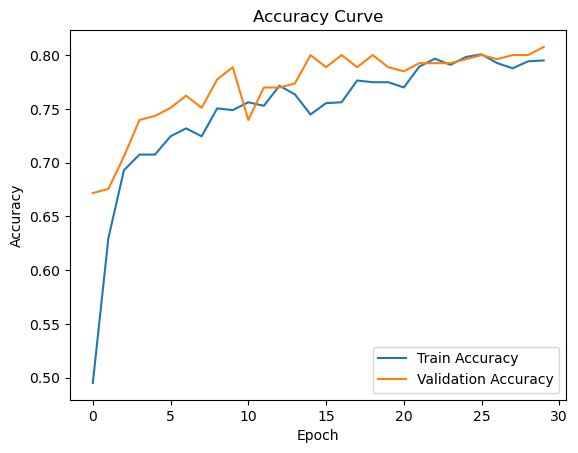

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

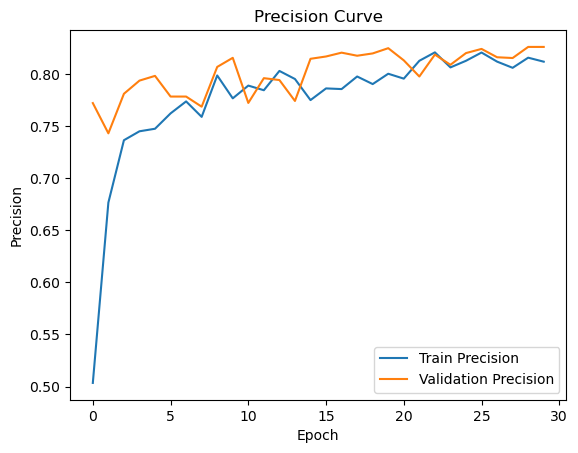

In [15]:
# PRECISION CURVE
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')

plt.title("Precision Curve")
plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.legend()
plt.show()

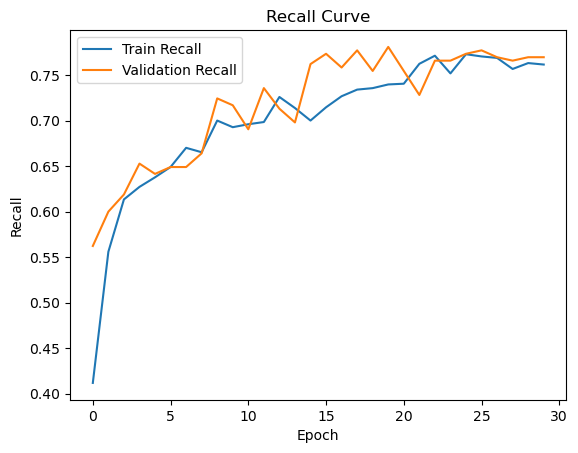

In [16]:
# RECALL CURVE
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')

plt.title("Recall Curve")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.legend()
plt.show()

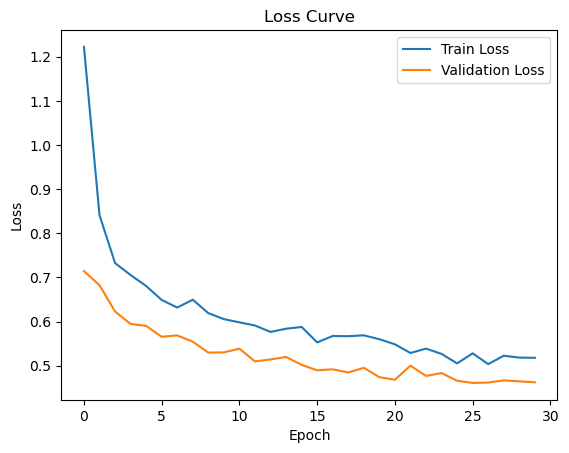

In [17]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [18]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 538ms/step - accuracy: 0.8189 - loss: 0.4216 - precision: 0.8353 - recall: 0.7849
Test Loss: 0.4216351807117462
Test Accuracy: 0.8188679218292236
Test Precision: 0.8353413939476013
Test Recall: 0.7849056720733643


In [19]:
# Predict probabilities
y_pred_probs = model.predict(test_generator)

# Convert probabilities to predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 615ms/step


In [20]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

     class_1       0.91      0.98      0.94       122
     class_2       0.82      0.62      0.70        86
     class_3       0.65      0.79      0.71        57

    accuracy                           0.82       265
   macro avg       0.79      0.79      0.79       265
weighted avg       0.82      0.82      0.81       265



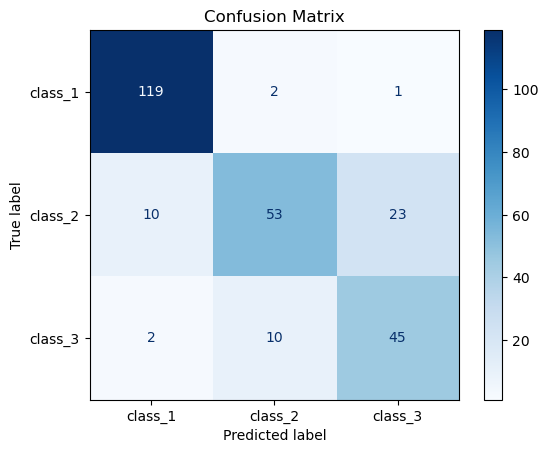

In [21]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")

plt.show()

In [22]:
# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Compute ROC-AUC
roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.9450233838829627
